# Grouped SHAP — HAR vs RF Comparison

Computes **group-level SHAP contributions** for both HAR (linear, exact) and RF (tree-based,
from pre-computed per-observation SHAP values), then compares how each model's reliance on
feature groups shifts across forecast horizons.

**HAR SHAP (linear, exact)**:
For a linear model: `SHAP_i(obs) = coef_i × (x_i - mean_train(x_i))`
Grouped by summing within-group contributions per observation, then taking `mean(|SHAP|)`.

**RF SHAP (TreeSHAP, interventional)**:
Loaded from pre-computed `shap_values.csv` per checkpoint, then grouped the same way.

Both use the full feature set `har_endo_exo_climate_news_macro` for comparability.

In [12]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

BENCHMARK_ROOT = PROJECT_ROOT / 'data' / 'benchmark'
DATA_ROOT = PROJECT_ROOT / 'data' / 'ag'

CROPS = {
    'wheat':   {'target': 'wheat_weekly_rv',    'csv': 'wheat.csv'},
    'corn':    {'target': 'corn_weekly_rv',      'csv': 'corn.csv'},
    'soybean': {'target': 'soybeans_weekly_rv',  'csv': 'soybean.csv'},
}
HORIZONS = [1, 4, 8, 12, 16]
FULL_FS = 'har_endo_exo_climate_news_macro'

# HAR model types to include (expanding window only for clean comparison)
HAR_MODELS = ['ols_expanding', 'lasso_expanding', 'bsr_expanding', 'group_lasso_expanding']

# Feature group display order and colors
GROUP_ORDER  = ['core', 'endo', 'exo', 'climate', 'news', 'macro']
GROUP_COLORS = {
    'core':    '#1f77b4',
    'endo':    '#ff7f0e',
    'exo':     '#2ca02c',
    'climate': '#d62728',
    'news':    '#9467bd',
    'macro':   '#8c564b',
}

OUTPUT_ROOT = BENCHMARK_ROOT / 'plots' / 'grouped_shap'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
SAVE_PLOTS = True

print(f'Project root : {PROJECT_ROOT}')
print(f'Output root  : {OUTPUT_ROOT}')

Project root : /Users/arshia/Projects/Papers/FinancialAI/Volf
Output root  : /Users/arshia/Projects/Papers/FinancialAI/Volf/data/benchmark/plots/grouped_shap


## 1. Feature-group classifier

Maps any feature name → group (core / endo / exo / climate / news / macro).

In [13]:
_CLIMATE_PREFIXES = ('ssta_', 'SOI_', 'NAO_', 'tmax_', 'tmin_', 'awnd_',
                     'spi_', 'pdsi_', 'co2_')
_NEWS_FEATURES    = {'frbsf_sentiment', 'Text_Climate_Anomaly', 'epu_index'}
_MACRO_FEATURES   = {'DJIA_Index', 'WTI_Index', 'Broad_Dollar_index', 'Stock_Uncertainty'}
_ALL_CROPS        = ('wheat', 'corn', 'soybeans')


def classify_feature(feat: str, target_col: str) -> str:
    """Return the feature group name for a given feature."""
    prefix = target_col.replace('_weekly_rv', '')

    # core HAR lags of the target crop
    if feat in {f'{prefix}_weekly_rv', f'{prefix}_monthly_rv', f'{prefix}_seasonal_rv'}:
        return 'core'

    # endogenous decomposition of the target crop
    if feat in {f'{prefix}_weekly_rvb', f'{prefix}_weekly_rvg', f'{prefix}_weekly_jumps'}:
        return 'endo'

    # cross-commodity RV (exo)
    if any(feat == f'{c}_weekly_rv' for c in _ALL_CROPS if c != prefix):
        return 'exo'

    if feat in _NEWS_FEATURES:
        return 'news'
    if feat in _MACRO_FEATURES:
        return 'macro'
    if any(feat.startswith(p) for p in _CLIMATE_PREFIXES):
        return 'climate'

    return 'other'


# Quick sanity check
_sample_feats = [
    'corn_weekly_rv', 'corn_monthly_rv', 'corn_weekly_rvb',
    'wheat_weekly_rv', 'NAO_index', 'frbsf_sentiment', 'DJIA_Index',
]
for f in _sample_feats:
    print(f'{f:40s} → {classify_feature(f, "corn_weekly_rv")}')

corn_weekly_rv                           → core
corn_monthly_rv                          → core
corn_weekly_rvb                          → endo
wheat_weekly_rv                          → exo
NAO_index                                → climate
frbsf_sentiment                          → news
DJIA_Index                               → macro


## 2. HAR SHAP (from saved shap_values.csv)

Reads the pre-computed per-observation SHAP values saved by .
Path: 

Same column layout as RF: , , , then one column per feature.

In [14]:
_HAR_META_COLS = {"base_value", "prediction_transformed", "prediction"}


def load_har_shap(
    crop: str,
    model_type: str,
    horizon: int,
    feature_set: str = FULL_FS,
) -> pd.DataFrame | None:
    """Load HAR shap_values.csv and return signed per-obs group contributions."""
    crop_info = CROPS[crop]
    shap_path = (
        BENCHMARK_ROOT / crop / "har" / "mean"
        / f"target_horizon_{horizon}" / "shap"
        / f"h{horizon}_mean_{model_type}_{feature_set}"
        / "shap_values.csv"
    )
    if not shap_path.exists():
        return None

    shap_raw  = pd.read_csv(shap_path, index_col=0)
    feat_cols = [c for c in shap_raw.columns if c not in _HAR_META_COLS]
    target_col = crop_info["target"]

    group_sums = pd.DataFrame(0.0, index=shap_raw.index, columns=GROUP_ORDER)
    for feat in feat_cols:
        grp = classify_feature(feat, target_col)
        if grp in group_sums.columns:
            group_sums[grp] += shap_raw[feat].fillna(0.0)

    return group_sums


# Smoke-test: wheat h=1
_test = load_har_shap("wheat", "bsr_expanding", 1)
if _test is not None:
    print("wheat h=1 bsr_expanding group mean-|SHAP|:")
    print(_test.abs().mean().round(5))
else:
    print("No shap_values.csv — run: uv run python -m scripts.benchmark.shap --config config/wheat/shap_har_mean.json")

wheat h=1 bsr_expanding group mean-|SHAP|:
core       0.15838
endo       0.00110
exo        0.00000
climate    0.00992
news       0.00000
macro      0.01276
dtype: float64


## 3. RF SHAP (TreeSHAP, pre-computed)

Load the pre-computed `shap_values.csv` (interventional TreeSHAP) from each RF checkpoint
and aggregate feature-level SHAP values to group level in the same way.

In [15]:
_RF_META_COLS = {'base_value', 'prediction_transformed', 'prediction'}


def load_rf_shap(
    crop: str,
    horizon: int,
    feature_set: str = FULL_FS,
) -> pd.DataFrame | None:
    """Return signed per-obs group SHAP contributions from pre-computed RF SHAP CSV."""
    crop_info = CROPS[crop]
    shap_path = (
        BENCHMARK_ROOT / crop / 'rf' / 'mean'
        / f'target_horizon_{horizon}' / 'shap'
        / f'h{horizon}_mean_rf_expanding_{feature_set}'
        / 'shap_values.csv'
    )
    if not shap_path.exists():
        return None

    shap_raw  = pd.read_csv(shap_path, index_col=0)
    feat_cols = [c for c in shap_raw.columns if c not in _RF_META_COLS]
    target_col = crop_info['target']

    group_sums = pd.DataFrame(0.0, index=shap_raw.index, columns=GROUP_ORDER)
    for feat in feat_cols:
        grp = classify_feature(feat, target_col)
        if grp in group_sums.columns:
            group_sums[grp] += shap_raw[feat]

    return group_sums


# Smoke-test: wheat h=1 RF
_test_rf = load_rf_shap('wheat', 1)
if _test_rf is not None:
    print('wheat h=1 RF group mean-|SHAP|:')
    print(_test_rf.abs().mean().round(6))
else:
    print('RF SHAP not found')

wheat h=1 RF group mean-|SHAP|:
core       0.001017
endo       0.000789
exo        0.000222
climate    0.000156
news       0.000183
macro      0.000268
dtype: float64


## 4. Aggregate across crops × models × horizons

For each `(crop, model, horizon)` combination:
1. Compute `mean(|group_shap|)` across test observations — this is the mean absolute group contribution.
2. Normalize to proportions (sum = 1) so HAR and RF are on a comparable scale.

In [16]:
records = []

for crop in CROPS:
    # --- HAR models ---
    for model_type in HAR_MODELS:
        for h in HORIZONS:
            grp_shap = load_har_shap(crop, model_type, h)
            if grp_shap is None:
                continue
            mean_abs = grp_shap.abs().mean()
            total    = mean_abs.sum()
            if total == 0:
                continue
            row = {'crop': crop, 'model': model_type, 'horizon': h, 'model_family': 'HAR'}
            for g in GROUP_ORDER:
                row[g] = mean_abs[g] / total
            records.append(row)

    # --- RF ---
    for h in HORIZONS:
        grp_shap = load_rf_shap(crop, h)
        if grp_shap is None:
            continue
        mean_abs = grp_shap.abs().mean()
        total    = mean_abs.sum()
        if total == 0:
            continue
        row = {'crop': crop, 'model': 'rf_expanding', 'horizon': h, 'model_family': 'RF'}
        for g in GROUP_ORDER:
            row[g] = mean_abs[g] / total
        records.append(row)

results = pd.DataFrame(records)
print(f'Total records: {len(results)}')
print(results.groupby(['model_family', 'model']).size().rename('n'))
results.head()

Total records: 30
model_family  model          
HAR           bsr_expanding       3
              lasso_expanding    12
RF            rf_expanding       15
Name: n, dtype: int64


,crop,model,horizon,model_family,core,endo,exo,climate,news,macro
0,wheat,lasso_expanding,4,HAR,0.700852,0.000000,0.015517,0.089553,0.015348,0.178730
1,wheat,lasso_expanding,8,HAR,0.576840,0.000488,0.000540,0.123733,0.055358,0.243041
2,wheat,lasso_expanding,12,HAR,0.514507,0.000715,0.004078,0.137887,0.072945,0.269869
3,wheat,lasso_expanding,16,HAR,0.470353,0.000000,0.017079,0.122477,0.071645,0.318447
4,wheat,bsr_expanding,1,HAR,0.869439,0.006062,0.000000,0.054431,0.000000,0.070068


## 5. Main plot — group contribution share by model × horizon

Each panel = one model. X-axis = horizon. Stacked bars = group share of total |SHAP|.
Averaged across crops.

**Key interpretation**: HAR stacks should stay core-heavy at all horizons;
RF stacks should shift toward climate/macro at longer horizons.

Saved → /Users/arshia/Projects/Papers/FinancialAI/Volf/data/benchmark/plots/grouped_shap/group_shap_by_model_horizon.png


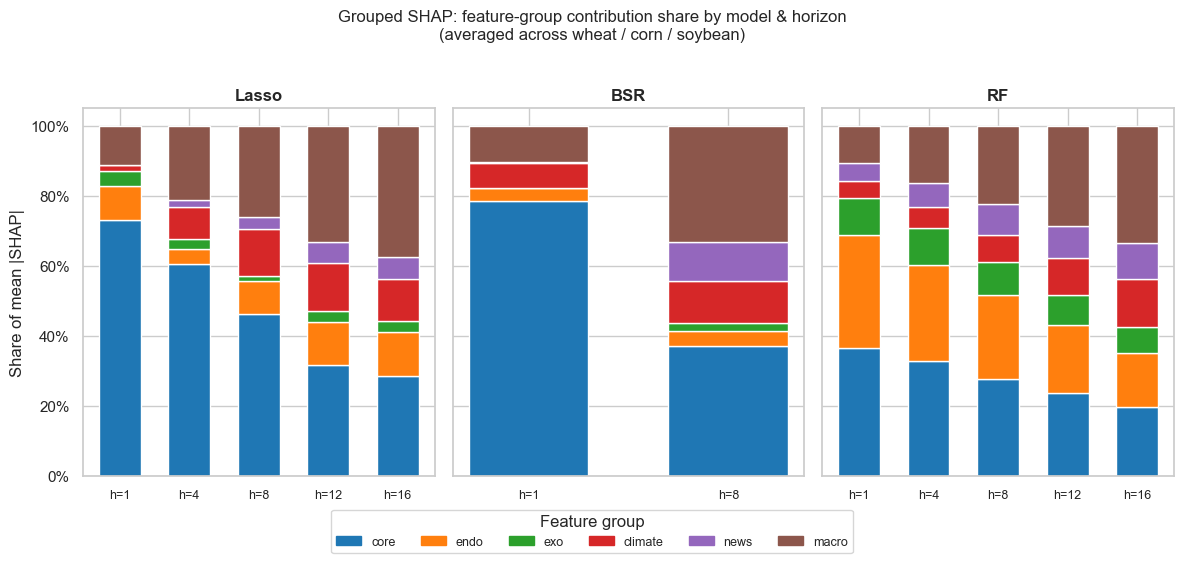

In [17]:
ALL_MODELS = HAR_MODELS + ['rf_expanding']
MODEL_LABELS = {
    'ols_expanding':        'OLS',
    'lasso_expanding':      'Lasso',
    'bsr_expanding':        'BSR',
    'group_lasso_expanding':'Group-Lasso',
    'rf_expanding':         'RF',
}

if results.empty:
    print('No results — run the benchmarks first.')
else:
    # Average across crops
    avg = (
        results.groupby(['model', 'horizon'])[GROUP_ORDER]
        .mean()
        .reset_index()
    )

    models_present = [m for m in ALL_MODELS if m in avg['model'].unique()]
    n_models = len(models_present)
    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 5), sharey=True)
    if n_models == 1:
        axes = [axes]

    for ax, model in zip(axes, models_present):
        sub = avg[avg['model'] == model].sort_values('horizon')
        bottom = np.zeros(len(sub))
        x = np.arange(len(sub))

        for grp in GROUP_ORDER:
            vals = sub[grp].values
            ax.bar(x, vals, bottom=bottom, color=GROUP_COLORS[grp],
                   label=grp, width=0.6)
            bottom += vals

        ax.set_xticks(x)
        ax.set_xticklabels([f'h={h}' for h in sub['horizon']], fontsize=9)
        ax.set_title(MODEL_LABELS.get(model, model), fontweight='bold')
        ax.set_ylim(0, 1.05)
        if ax is axes[0]:
            ax.set_ylabel('Share of mean |SHAP|')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

    handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COLORS[g]) for g in GROUP_ORDER]
    fig.legend(handles, GROUP_ORDER, title='Feature group',
               loc='lower center', ncol=len(GROUP_ORDER),
               bbox_to_anchor=(0.5, -0.08), fontsize=9)

    fig.suptitle('Grouped SHAP: feature-group contribution share by model & horizon\n(averaged across wheat / corn / soybean)',
                 fontsize=12, y=1.02)
    plt.tight_layout()

    if SAVE_PLOTS:
        path = OUTPUT_ROOT / 'group_shap_by_model_horizon.png'
        fig.savefig(path, dpi=150, bbox_inches='tight')
        print(f'Saved → {path}')
    plt.show()

## 6. RF vs best-HAR comparison — line plot per group

Line chart showing how each group's share evolves with horizon for RF vs the HAR ensemble.
Highlights the divergence in reliance on climate/macro at long horizons.

Saved → /Users/arshia/Projects/Papers/FinancialAI/Volf/data/benchmark/plots/grouped_shap/har_vs_rf_group_shap_lines.png


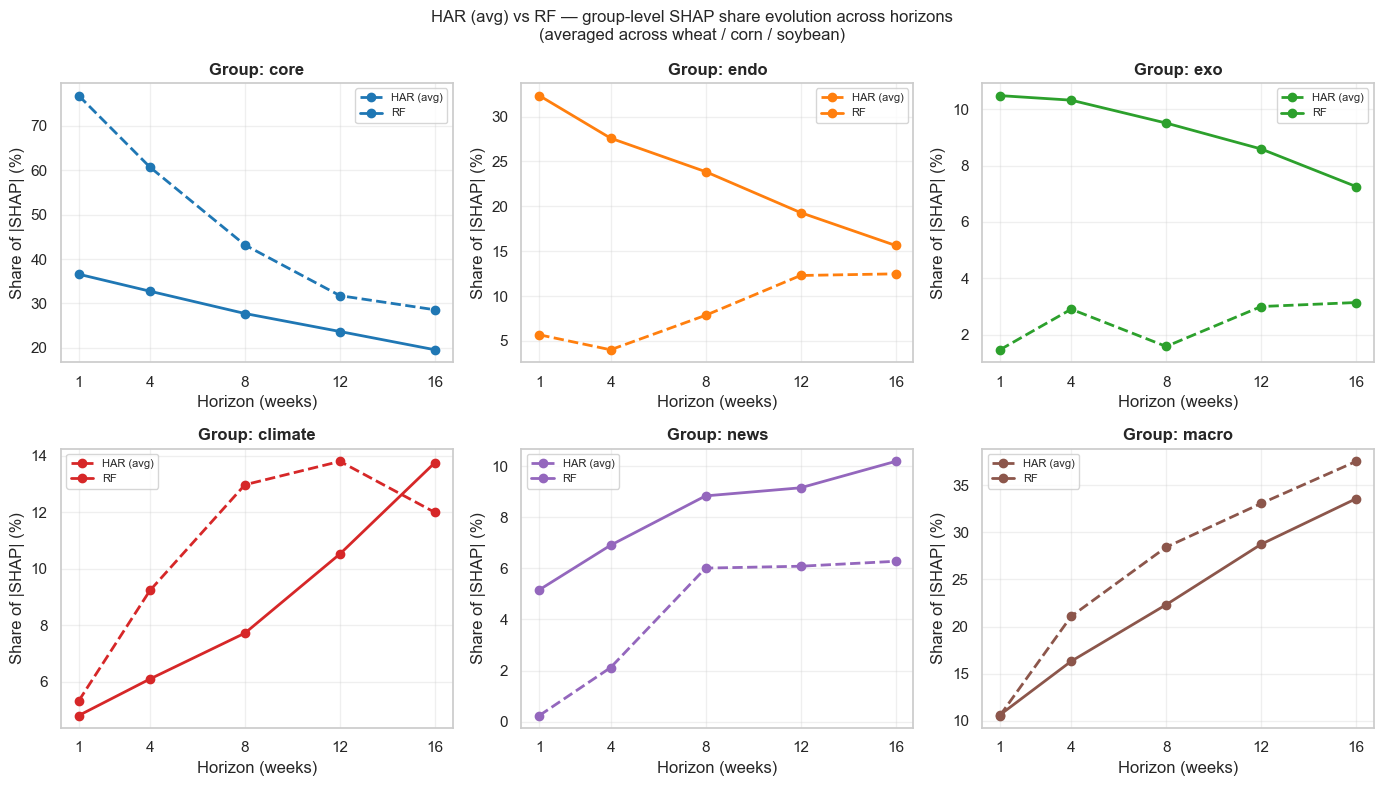

In [18]:
if results.empty:
    print('No results — run the benchmarks first.')
else:
    # Average HAR models together, keep RF separate
    har_avg = (
        results[results['model_family'] == 'HAR']
        .groupby('horizon')[GROUP_ORDER].mean()
        .assign(model='HAR (avg)')
    )
    rf_avg = (
        results[results['model_family'] == 'RF']
        .groupby('horizon')[GROUP_ORDER].mean()
        .assign(model='RF')
    )
    comparison = pd.concat([har_avg.reset_index(), rf_avg.reset_index()])

    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
    axes = axes.flatten()

    for idx, grp in enumerate(GROUP_ORDER):
        ax = axes[idx]
        for model_label, style in [('HAR (avg)', '--'), ('RF', '-')]:
            sub = comparison[comparison['model'] == model_label]
            if sub.empty:
                continue
            ax.plot(sub['horizon'], sub[grp] * 100,
                    marker='o', linestyle=style,
                    color=GROUP_COLORS[grp],
                    linewidth=2,
                    label=model_label)
        ax.set_title(f'Group: {grp}', fontweight='bold')
        ax.set_xlabel('Horizon (weeks)')
        ax.set_ylabel('Share of |SHAP| (%)')
        ax.set_xticks(HORIZONS)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    # Hide unused subplot(s)
    for i in range(len(GROUP_ORDER), len(axes)):
        axes[i].set_visible(False)

    fig.suptitle('HAR (avg) vs RF — group-level SHAP share evolution across horizons\n(averaged across wheat / corn / soybean)',
                 fontsize=12)
    plt.tight_layout()

    if SAVE_PLOTS:
        path = OUTPUT_ROOT / 'har_vs_rf_group_shap_lines.png'
        fig.savefig(path, dpi=150, bbox_inches='tight')
        print(f'Saved → {path}')
    plt.show()

## 7. Per-crop breakdown

Same stacked bars but faceted by crop (rows) × model (columns) at the longest horizon (h=16),
to see whether the climate-shift pattern is consistent across commodities.

Saved → /Users/arshia/Projects/Papers/FinancialAI/Volf/data/benchmark/plots/grouped_shap/group_shap_h16_crop_breakdown.png


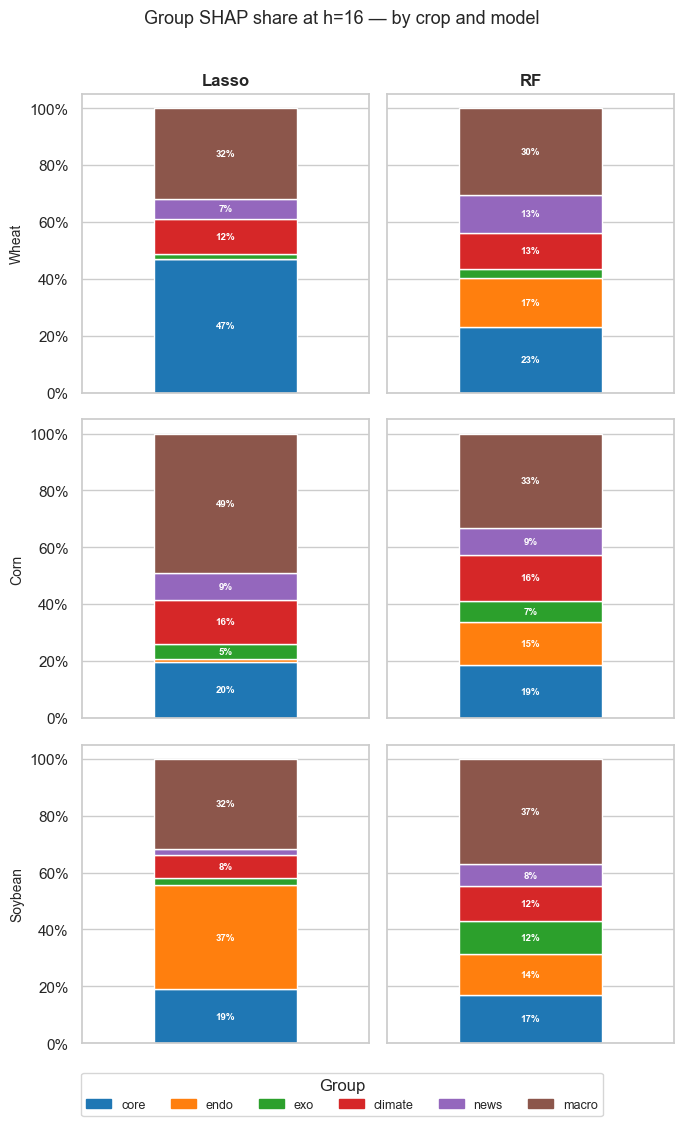

In [19]:
FOCUS_HORIZON = 16

if results.empty:
    print('No results — run the benchmarks first.')
else:
    sub16 = results[results['horizon'] == FOCUS_HORIZON]
    crops_present  = [c for c in CROPS  if c in sub16['crop'].unique()]
    models_present = [m for m in ALL_MODELS if m in sub16['model'].unique()]

    n_rows = len(crops_present)
    n_cols = len(models_present)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3.5 * n_cols, 3.5 * n_rows),
                             sharey=True, squeeze=False)

    for r, crop in enumerate(crops_present):
        for c, model in enumerate(models_present):
            ax = axes[r][c]
            row = sub16[(sub16['crop'] == crop) & (sub16['model'] == model)]
            if row.empty:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                        transform=ax.transAxes, color='grey')
                ax.set_xticks([])
                continue

            bottom = 0.0
            for grp in GROUP_ORDER:
                val = float(row[grp].iloc[0])
                ax.bar([0], [val], bottom=bottom, color=GROUP_COLORS[grp], width=0.5)
                if val > 0.05:
                    ax.text(0, bottom + val / 2, f'{val:.0%}',
                            ha='center', va='center', fontsize=7, color='white', fontweight='bold')
                bottom += val

            ax.set_xlim(-0.5, 0.5)
            ax.set_ylim(0, 1.05)
            ax.set_xticks([])
            if c == 0:
                ax.set_ylabel(crop.capitalize(), fontsize=10)
            if r == 0:
                ax.set_title(MODEL_LABELS.get(model, model), fontweight='bold')
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

    handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COLORS[g]) for g in GROUP_ORDER]
    fig.legend(handles, GROUP_ORDER, title='Group',
               loc='lower center', ncol=len(GROUP_ORDER),
               bbox_to_anchor=(0.5, -0.05), fontsize=9)

    fig.suptitle(f'Group SHAP share at h={FOCUS_HORIZON} — by crop and model', fontsize=13, y=1.01)
    plt.tight_layout()

    if SAVE_PLOTS:
        path = OUTPUT_ROOT / f'group_shap_h{FOCUS_HORIZON}_crop_breakdown.png'
        fig.savefig(path, dpi=150, bbox_inches='tight')
        print(f'Saved → {path}')
    plt.show()

## 8. Summary table

Numeric summary: mean group shares at h=1 and h=16 for each model, averaged across crops.

In [20]:
if not results.empty:
    summary = (
        results[results['horizon'].isin([1, 16])]
        .groupby(['model', 'horizon'])[GROUP_ORDER]
        .mean()
        .mul(100)
        .round(1)
    )
    summary.columns = [f'{g} %' for g in GROUP_ORDER]
    summary.index.names = ['model', 'h']
    print(summary.to_string())
else:
    print('No results yet.')

                    core %  endo %  exo %  climate %  news %  macro %
model           h                                                    
bsr_expanding   1     78.5     3.8    0.0        7.1     0.3     10.3
lasso_expanding 1     73.2     9.4    4.4        1.8     0.0     11.1
                16    28.6    12.5    3.1       12.0     6.3     37.5
rf_expanding    1     36.6    32.3   10.5        4.8     5.2     10.6
                16    19.6    15.6    7.3       13.8    10.2     33.6
